In [2]:
import pandas as pd 
import matplotlib.pyplot as plt 
df=pd.read_csv("survey_results_public.csv")

In [3]:
df.head()

,Respondent,MainBranch,Hobbyist,Age,Age1stCode,CompFreq,CompTotal,ConvertedComp,Country,CurrencyDesc,...,SurveyEase,SurveyLength,Trans,UndergradMajor,WebframeDesireNextYear,WebframeWorkedWith,WelcomeChange,WorkWeekHrs,YearsCode,YearsCodePro
0,1,I am a developer by profession,Yes,NaN,13,Monthly,NaN,NaN,Germany,European Euro,...,Neither easy nor difficult,Appropriate in length,No,"Computer science, computer engineering, or sof...",ASP.NET Core,ASP.NET;ASP.NET Core,Just as welcome now as I felt last year,50.0,36,27
1,2,I am a developer by profession,No,NaN,19,NaN,NaN,NaN,United Kingdom,Pound sterling,...,NaN,NaN,NaN,"Computer science, computer engineering, or sof...",NaN,NaN,Somewhat more welcome now than last year,NaN,7,4
2,3,I code primarily as a hobby,Yes,NaN,15,NaN,NaN,NaN,Russian Federation,NaN,...,Neither easy nor difficult,Appropriate in length,NaN,NaN,NaN,NaN,Somewhat more welcome now than last year,NaN,4,NaN
3,4,I am a developer by profession,Yes,25.0,18,NaN,NaN,NaN,Albania,Albanian lek,...,NaN,NaN,No,"Computer science, computer engineering, or sof...",NaN,NaN,Somewhat less welcome now than last year,40.0,7,4
4,5,"I used to be a developer by profession, but no...",Yes,31.0,16,NaN,NaN,NaN,United States,NaN,...,Easy,Too short,No,"Computer science, computer engineering, or sof...",Django;Ruby on Rails,Ruby on Rails,Just as welcome now as I felt last year,NaN,15,8


In [4]:
df=df[["Country","EdLevel","YearsCodePro","Employment","ConvertedComp"]] #keeping only selected columns from 
df=df.rename({"ConvertedComp":"Salary"},axis=1)
df.head()



,Country,EdLevel,YearsCodePro,Employment,Salary
0,Germany,"Master’s degree (M.A., M.S., M.Eng., MBA, etc.)",27,"Independent contractor, freelancer, or self-em...",NaN
1,United Kingdom,"Bachelor’s degree (B.A., B.S., B.Eng., etc.)",4,Employed full-time,NaN
2,Russian Federation,NaN,NaN,NaN,NaN
3,Albania,"Master’s degree (M.A., M.S., M.Eng., MBA, etc.)",4,NaN,NaN
4,United States,"Bachelor’s degree (B.A., B.S., B.Eng., etc.)",8,Employed full-time,NaN


In [5]:
df=df[df["Salary"].notnull()]
df.head()

,Country,EdLevel,YearsCodePro,Employment,Salary
7,United States,"Bachelor’s degree (B.A., B.S., B.Eng., etc.)",13,Employed full-time,116000.0
9,United Kingdom,"Master’s degree (M.A., M.S., M.Eng., MBA, etc.)",4,Employed full-time,32315.0
10,United Kingdom,"Bachelor’s degree (B.A., B.S., B.Eng., etc.)",2,Employed full-time,40070.0
11,Spain,Some college/university study without earning ...,7,Employed full-time,14268.0
12,Netherlands,"Secondary school (e.g. American high school, G...",20,Employed full-time,38916.0


In [6]:
df.info()  

<class 'pandas.core.frame.DataFrame'>
Index: 34756 entries, 7 to 64154
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Country       34756 non-null  object 
 1   EdLevel       34188 non-null  object 
 2   YearsCodePro  34621 non-null  object 
 3   Employment    34717 non-null  object 
 4   Salary        34756 non-null  float64
dtypes: float64(1), object(4)
memory usage: 1.6+ MB


In [7]:
df=df.dropna() # dropping the column which are not a number 
df.isnull().sum() #we are getting zero which means we are not having any mising values  

Country         0
EdLevel         0
YearsCodePro    0
Employment      0
Salary          0
dtype: int64

In [8]:
df=df[df["Employment"]=="Employed full-time"]
df=df.drop("Employment",axis=1)
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 30019 entries, 7 to 64154
Data columns (total 4 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Country       30019 non-null  object 
 1   EdLevel       30019 non-null  object 
 2   YearsCodePro  30019 non-null  object 
 3   Salary        30019 non-null  float64
dtypes: float64(1), object(3)
memory usage: 1.1+ MB


In [9]:
df['Country'].value_counts()

Country
United States     7569
India             2425
United Kingdom    2287
Germany           1903
Canada            1178
                  ... 
Swaziland            1
Niger                1
Belize               1
Yemen                1
Andorra              1
Name: count, Length: 154, dtype: int64

In [10]:
def shorten_categories(categories,cutoff):
    categorical_map={}
    for i in range(len(categories)):
        if categories.values[i]>= cutoff:
            categorical_map[categories.index[i]]=categories.index[i]
        else:
            categorical_map[categories.index[i]]='Other'
    return  categorical_map      
            

In [11]:
country_map=shorten_categories(df.Country.value_counts(),400)
df['Country']=df['Country'].map(country_map) # now we are having the values greater than the cutoff in Country column 

df.Country.value_counts()


Country
Other                 8549
United States         7569
India                 2425
United Kingdom        2287
Germany               1903
Canada                1178
Brazil                 991
France                 972
Spain                  670
Australia              659
Netherlands            654
Poland                 566
Italy                  560
Russian Federation     522
Sweden                 514
Name: count, dtype: int64

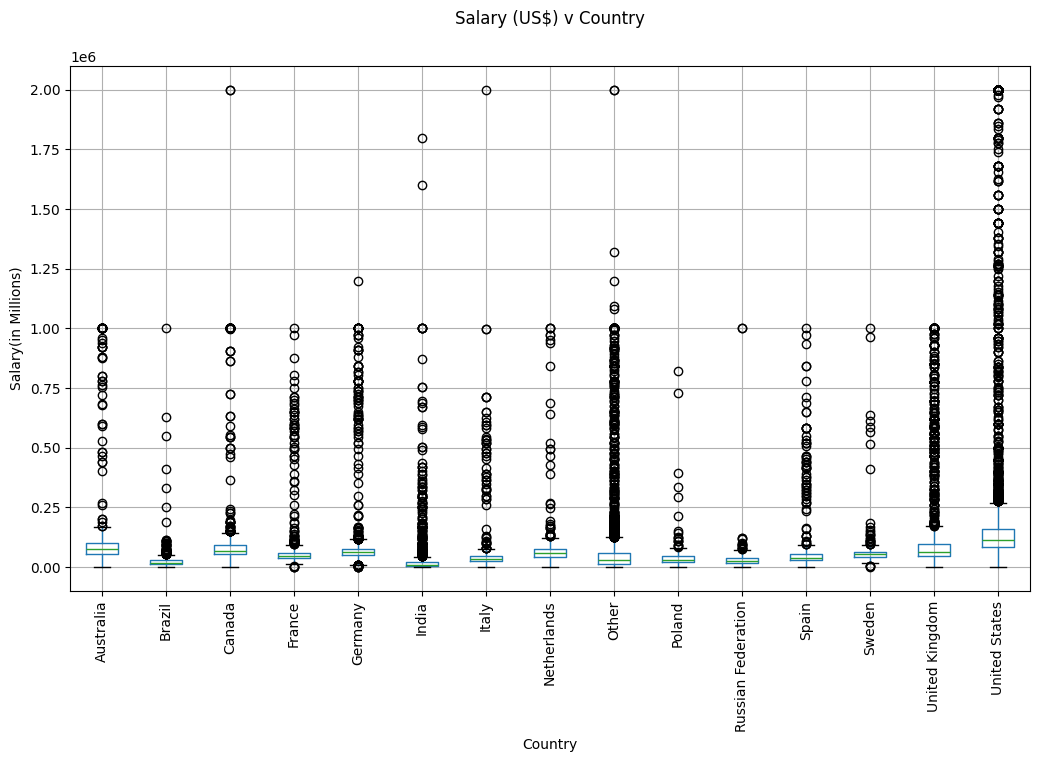

In [12]:
fig, ax=plt.subplots(1,1,figsize=(12,7))
df.boxplot('Salary','Country' ,ax=ax)
plt.suptitle('Salary (US$) v Country')
plt.title(' ')
plt.ylabel('Salary(in Millions)')
plt.xticks(rotation=90)
plt.show()              

In [13]:
df=df[df["Salary"]<=250000] # keeps rows with Salary ≤ 250000

df=df[df["Salary"] >= 10000] #keeps rows with Salary ≥ 10000

df=df[df['Country']!='Other']#removes rows where Country is "Others"

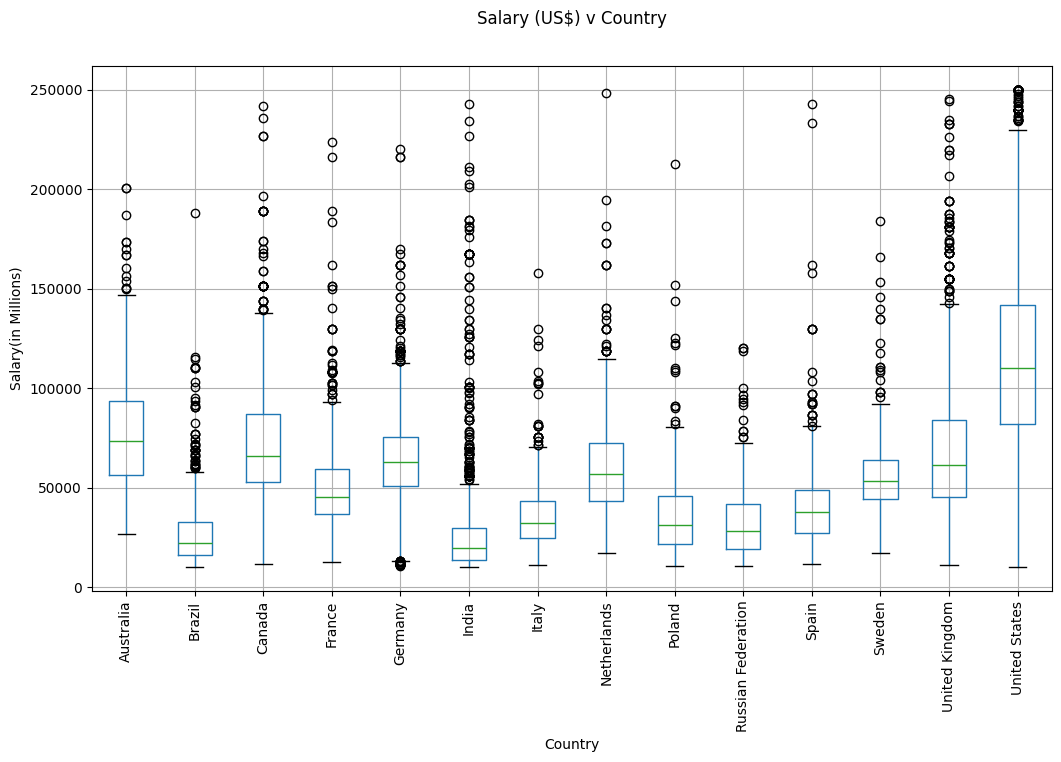

In [14]:
fig, ax=plt.subplots(1,1,figsize=(12,7))
df.boxplot('Salary','Country' ,ax=ax)     # Boxplot tells the middle value(median) of dataset(here salary)
plt.suptitle('Salary (US$) v Country')
plt.title(' ')
plt.ylabel('Salary(in Millions)')
plt.xticks(rotation=90)
plt.show()               #So now wee are havin the graph with less outliers 

In [15]:
 df["YearsCodePro"].unique()

array(['13', '4', '2', '7', '20', '1', '3', '10', '12', '29', '6', '28',
       '8', '23', '15', '25', '9', '11', 'Less than 1 year', '5', '21',
       '16', '18', '14', '32', '19', '22', '38', '30', '26', '27', '17',
       '24', '34', '35', '33', '36', '40', '39', 'More than 50 years',
       '31', '37', '41', '45', '42', '44', '43', '50', '49'], dtype=object)

In [16]:
def clean_experience(x):        #cleaning
    if x=='More than 50 years':
        return 50
    if x=='Less than 1 year':
        return 0.5
    return float(x)       #flaot is used to convert the values which are in string to float (numeric) values
df["YearsCodePro"]=df["YearsCodePro"].apply(clean_experience)

In [17]:
 df["YearsCodePro"].unique()

array([13. ,  4. ,  2. ,  7. , 20. ,  1. ,  3. , 10. , 12. , 29. ,  6. ,
       28. ,  8. , 23. , 15. , 25. ,  9. , 11. ,  0.5,  5. , 21. , 16. ,
       18. , 14. , 32. , 19. , 22. , 38. , 30. , 26. , 27. , 17. , 24. ,
       34. , 35. , 33. , 36. , 40. , 39. , 50. , 31. , 37. , 41. , 45. ,
       42. , 44. , 43. , 49. ])

In [18]:
df['EdLevel'].unique()

array(['Bachelor’s degree (B.A., B.S., B.Eng., etc.)',
       'Master’s degree (M.A., M.S., M.Eng., MBA, etc.)',
       'Some college/university study without earning a degree',
       'Secondary school (e.g. American high school, German Realschule or Gymnasium, etc.)',
       'Associate degree (A.A., A.S., etc.)',
       'Professional degree (JD, MD, etc.)',
       'Other doctoral degree (Ph.D., Ed.D., etc.)',
       'I never completed any formal education',
       'Primary/elementary school'], dtype=object)

In [19]:
def clean_eductaion(x):         # as we are having multiple string values of ed_level so we are taking only those which are important 
    if 'Bachelor’s degree' in x:
        return 'Bachelor’s degree'
    if 'Master’s degree' in x:
        return 'Master’s degree'
    if 'Professional degree' in x or 'Other doctoral' in x:
        return 'Post grad'
    return 'Less than a Bachelor'
df['EdLevel']=df['EdLevel'].apply(clean_eductaion)

In [20]:
 df['EdLevel'].unique()

array(['Bachelor’s degree', 'Master’s degree', 'Less than a Bachelor',
       'Post grad'], dtype=object)

In [21]:
from sklearn.preprocessing import LabelEncoder      # assigning numerical values to the four degree
le_education=LabelEncoder()
df['EdLevel']=le_education.fit_transform(df['EdLevel'])
df['EdLevel'].unique()

array([0, 2, 1, 3])

In [22]:
le_country=LabelEncoder()
df['Country']=le_country.fit_transform(df['Country'])
df['Country'].unique()

array([13, 12, 10,  7,  4,  2,  6,  1,  3,  5, 11,  8,  0,  9])

In [23]:
X=df.drop("Salary",axis=1)
y=df["Salary"]

In [24]:
from sklearn.linear_model import LinearRegression
linear_reg=LinearRegression()
linear_reg.fit(X,y.values)  # giving model the values 

LinearRegression()

In [25]:
y_pred=linear_reg.predict(X)  # trained linear regression model to predict the target values (y_pred) based on the input features X.

In [26]:
from sklearn.metrics import mean_squared_error, mean_absolute_error
import numpy as np
error=np.sqrt(mean_absolute_error(y,y_pred))

In [27]:
error

np.float64(174.58468595737105)

In [28]:
from sklearn.tree import DecisionTreeRegressor
dec_tree_reg=DecisionTreeRegressor(random_state=0)
dec_tree_reg.fit(X,y.values)

DecisionTreeRegressor(random_state=0)

In [29]:
y_pred=dec_tree_reg.predict(X)

In [30]:
error=np.sqrt(mean_absolute_error(y,y_pred))
error

np.float64(141.3242223963303)

In [31]:
from sklearn.ensemble import RandomForestRegressor
random_forest_reg=RandomForestRegressor(random_state=0) #Setting random_state You will get the same result every time you run the code.

#If you don't set it, results may change each time due to internal randomness.


random_forest_reg.fit(X,y.values)

RandomForestRegressor(random_state=0)

In [32]:
y_pred=random_forest_reg.predict(X)

In [33]:
error=np.sqrt(mean_absolute_error(y,y_pred))
error

np.float64(142.00760711952324)

In [34]:
from sklearn.model_selection import GridSearchCV   # we are doing this so as to get the best classifier based on diffenrt paramaters 
max_depth=[None,2,4,6,8,10,12]
parameters= {"max_depth":max_depth}

regressor=DecisionTreeRegressor(random_state=0)
gs=GridSearchCV(regressor,parameters, scoring='neg_mean_squared_error')
gs.fit(X,y.values)

GridSearchCV(estimator=DecisionTreeRegressor(random_state=0),
             param_grid={'max_depth': [None, 2, 4, 6, 8, 10, 12]},
             scoring='neg_mean_squared_error')

In [35]:
regressor=gs.best_estimator_
regressor.fit(X,y.values)
y_pred=regressor.predict(X)
error=np.sqrt(mean_absolute_error(y,y_pred))
error


np.float64(145.1813737160541)

In [36]:
X

,Country,EdLevel,YearsCodePro
7,13,0,13.0
9,12,2,4.0
10,12,0,2.0
11,10,1,7.0
12,7,1,20.0
...,...,...,...
64113,13,1,15.0
64116,13,0,6.0
64122,13,1,4.0
64127,13,3,12.0


In [37]:
X=np.array([['United States','Master’s degree',15]])
X

array([['United States', 'Master’s degree', '15']], dtype='<U21')

In [38]:
X[:,0]=le_country.transform(X[:,0])  X[:,0]  #Accesses all rows and 1st column of the matrix X.
X[:,1]=le_education.transform(X[:,1])
X=X.astype(float)
X

array([[13.,  2., 15.]])

In [39]:
y_pred=regressor.predict(X)  u#using above array X we have predict the salary 
y_pred

C:\Users\manjo\OneDrive\Desktop\ML\venv\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but DecisionTreeRegressor was fitted with feature names
  warnings.warn(


array([139427.26315789])

In [40]:
import pickle

In [41]:
data={"model":regressor,"le_country":le_country,"le_education":le_education}
with open('saved_step.pkl','wb') as file:
    pickle.dump(data,file)  # passing the above data to the pkl file


In [44]:
with open('saved_step.pkl','rb') as file:
    data=pickle.load(file)

regressor_loaded=data["model"]
le_country=data["le_country"]
le_education=data["le_education"]

In [45]:
y_pred=regressor_loaded.predict(X)  # so we get the same value as the value we get from orignal model 
y_pred

C:\Users\manjo\OneDrive\Desktop\ML\venv\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but DecisionTreeRegressor was fitted with feature names
  warnings.warn(


array([139427.26315789])